In [1]:
import json
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
# 1. Your JSON graph data
json_data = """
[
  {
    "source": "Incubation",
    "relation": "is",
    "target": "process of providing specific, controlled conditions"
  },
  {
    "source": "specific, controlled conditions",
    "relation": "include",
    "target": "temperature"
  },
  {
    "source": "specific, controlled conditions",
    "relation": "include",
    "target": "humidity"
  },
  {
    "source": "specific, controlled conditions",
    "relation": "include",
    "target": "atmosphere"
  },
  {
    "source": "Incubation",
    "relation": "facilitates",
    "target": "development"
  },
  {
    "source": "Incubation",
    "relation": "facilitates",
    "target": "growth"
  }
]
"""

# 2. Parse the JSON string into a Python list of dictionaries
edges_list = json.loads(json_data)

In [3]:
json_data

'\n[\n  {\n    "source": "Incubation",\n    "relation": "is",\n    "target": "process of providing specific, controlled conditions"\n  },\n  {\n    "source": "specific, controlled conditions",\n    "relation": "include",\n    "target": "temperature"\n  },\n  {\n    "source": "specific, controlled conditions",\n    "relation": "include",\n    "target": "humidity"\n  },\n  {\n    "source": "specific, controlled conditions",\n    "relation": "include",\n    "target": "atmosphere"\n  },\n  {\n    "source": "Incubation",\n    "relation": "facilitates",\n    "target": "development"\n  },\n  {\n    "source": "Incubation",\n    "relation": "facilitates",\n    "target": "growth"\n  }\n]\n'

In [4]:
type(json_data)

str

In [5]:
edges_list

[{'source': 'Incubation',
  'relation': 'is',
  'target': 'process of providing specific, controlled conditions'},
 {'source': 'specific, controlled conditions',
  'relation': 'include',
  'target': 'temperature'},
 {'source': 'specific, controlled conditions',
  'relation': 'include',
  'target': 'humidity'},
 {'source': 'specific, controlled conditions',
  'relation': 'include',
  'target': 'atmosphere'},
 {'source': 'Incubation', 'relation': 'facilitates', 'target': 'development'},
 {'source': 'Incubation', 'relation': 'facilitates', 'target': 'growth'}]

In [6]:
type(edges_list)

list

In [7]:
# 3. Initialize a NetworkX Directed Graph (DiGraph)
# We use DiGraph because relationships have a direction (source -> target)
G = nx.DiGraph()

In [8]:
# 4. Loop through the data to add nodes, edges, and edge attributes (the relations)
for item in edges_list:
    source = item["source"]
    target = item["target"]
    relation = item["relation"]
    
    # add_edge automatically creates the nodes if they don't exist yet
    # We store the 'relation' as an edge attribute called 'label'
    G.add_edge(source, target, label=relation)

/opt/apps/intel19/python3/3.7.0/lib/python3.7/site-packages/ipykernel_launcher.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


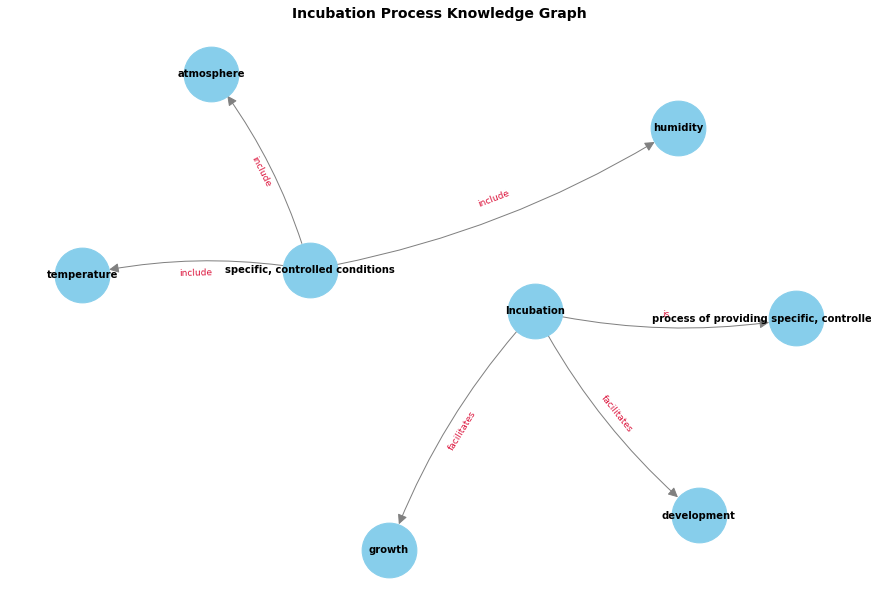

In [11]:
# 5. Set up the visual layout of the graph
# Figure size is set to 12x8 inches to give the text breathing room
plt.figure(figsize=(12, 8))

# 'spring_layout' positions nodes using a force-directed algorithm so they spread out nicely
# k controls the optimal distance between nodes; higher values mean more spacing
pos = nx.spring_layout(G, k=1.5, seed=42)

# 6. Draw the basic graph elements (Nodes and Edges)
nx.draw(
    G,
    pos,
    with_labels=True,  # Draws the names of the nodes inside/near them
    node_color="skyblue",  # Fills the node circles with a soft blue
    node_size=3000,  # Size of the node circles
    font_size=10,  # Font size for node labels
    font_weight="bold",  # Makes node text easier to read
    edge_color="gray",  # Color of the relationship lines
    arrows=True,  # Draws arrows pointing from source to target
    arrowsize=20,  # Size of the arrowheads
    connectionstyle="arc3,rad=0.1",  # Slightly curves the lines so they look elegant
)

# 7. Extract and draw the edge labels (the 'relations')
# Get a dictionary of all edge attributes keyed by edge tuples: e.g., {('Incubation', 'growth'): 'facilitates'}
edge_labels = nx.get_edge_attributes(G, "label")

# Draw these labels directly onto the lines in the plot
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_color="crimson",  # Distinct color for relationships
    font_size=9,
)

# 8. Display the finished visualization
plt.title("Incubation Process Knowledge Graph", fontsize=14, fontweight="bold")
plt.axis("off")  # Hides the standard X/Y graph axes for a cleaner look
plt.tight_layout()  # Adjusts margins so nothing gets cut off
plt.show()